In [2]:
from wavelet_class import *

import pandas as pd
import xarray as xr
import numpy as np

In [3]:
series = pd.read_csv("~/signal-extraction/results/mimoae_base/mimoae_base_extractr_results_latent.csv")

In [22]:
series = series.set_index('time')

In [23]:
series

,latent
time,
1940-01-16 00:00:00,0.676700
1940-02-15 00:00:00,0.530711
1940-03-16 00:00:00,0.781887
1940-04-15 12:00:00,1.039252
1940-05-16 00:00:00,1.067951
...,...
2025-02-14 12:00:00,0.727195
2025-03-16 00:00:00,0.835959
2025-04-15 12:00:00,1.040776


In [7]:
series['time'] = pd.to_datetime(series['time'])

In [9]:
wa = WaveletAnalyzer(WaveletConfig(dt=1, dj=0.025))

In [11]:
wlt = wa.cwt(series['latent'])

In [12]:
wlt_red = wa.confidence_interval(wlt, series['latent'], conf=0.95, noise_type="r")

Red Noise AR1 Coefficient: 0.9894779934063982


In [13]:
recon, sig_scales = wa.reconstruct(wlt_red, series['latent'])

Significant scales (within COI):
[ 2.    2.03  2.07  2.11  2.14  2.18  2.22  2.26  2.3   2.34  2.38  2.42
  2.46  2.51  2.55  2.59  2.64  2.69  2.73  2.78  2.83  2.88  2.93  2.98
  3.03  3.08  3.14  3.19  3.25  3.31  3.36  3.42  3.48  3.54  3.61  3.67
  3.73  3.8   3.86  3.93  4.    4.07  4.14  4.21  4.29  4.36  4.44  4.52
  4.59  4.68  4.76  4.84  4.92  5.01  5.1   5.19  5.28  5.37  5.46  5.56
  5.66  5.76  5.86  5.96  6.06  6.17  6.28  6.39  6.5   6.61  6.73  6.84
  6.96  7.09  7.21  7.34  7.46  7.59  7.73  7.86  8.    8.14  8.28  8.43
  8.57  8.72  8.88  9.03  9.19  9.35  9.51  9.68  9.85 10.02 10.2  10.37
 10.56 10.74 10.93 11.12 11.31 11.51 11.71 11.92 12.13 12.34 12.55 12.77
 13.   13.22 13.45 13.69 13.93 14.17 14.42 14.67 14.93 15.19 15.45 15.73
 16.   16.28 16.56 16.85 17.15 17.45 17.75 18.06 18.38 18.7  19.03 19.36
 19.7  20.04 20.39 20.75 21.11 21.48 21.86 22.24 22.63 23.02 23.43 23.83
 24.25 24.68 25.11 25.55 25.99 26.45 26.91 27.38]


Processing latent ...
Red Noise AR1 Coefficient: 0.9894779934063982


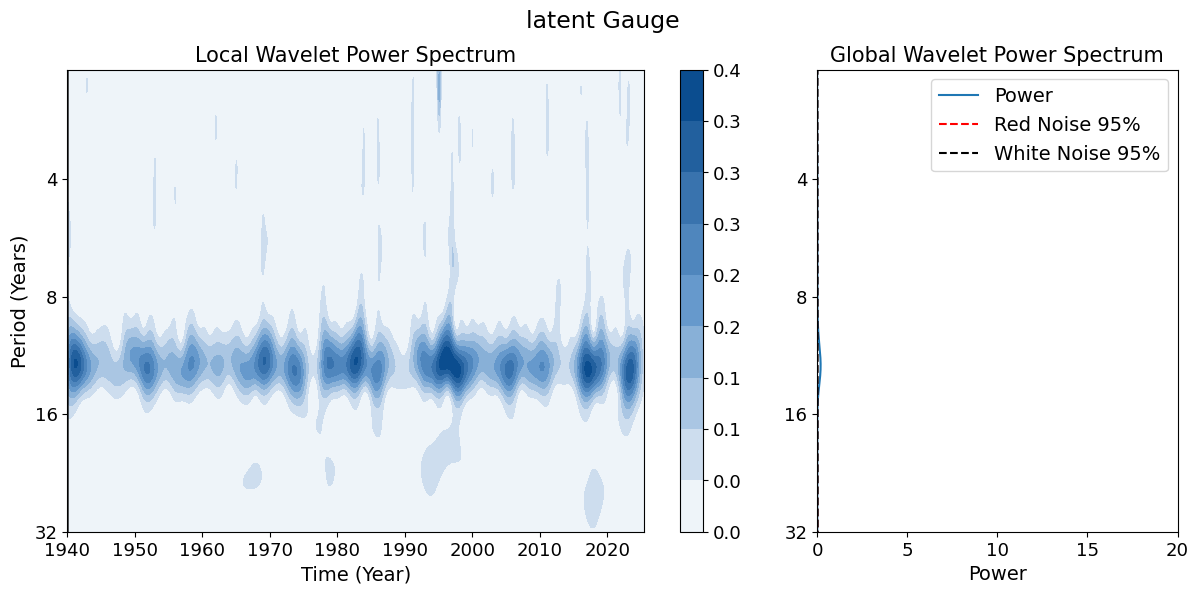

Red Noise Sig Test Results
Significant scales (within COI):
[ 2.    2.03  2.07  2.11  2.14  2.18  2.22  2.26  2.3   2.34  2.38  2.42
  2.46  2.51  2.55  2.59  2.64  2.69  2.73  2.78  2.83  2.88  2.93  2.98
  3.03  3.08  3.14  3.19  3.25  3.31  3.36  3.42  3.48  3.54  3.61  3.67
  3.73  3.8   3.86  3.93  4.    4.07  4.14  4.21  4.29  4.36  4.44  4.52
  4.59  4.68  4.76  4.84  4.92  5.01  5.1   5.19  5.28  5.37  5.46  5.56
  5.66  5.76  5.86  5.96  6.06  6.17  6.28  6.39  6.5   6.61  6.73  6.84
  6.96  7.09  7.21  7.34  7.46  7.59  7.73  7.86  8.    8.14  8.28  8.43
  8.57  8.72  8.88  9.03  9.19  9.35  9.51  9.68  9.85 10.02 10.2  10.37
 10.56 10.74 10.93 11.12 11.31 11.51 11.71 11.92 12.13 12.34 12.55 12.77
 13.   13.22 13.45 13.69 13.93 14.17 14.42 14.67 14.93 15.19 15.45 15.73
 16.   16.28 16.56 16.85 17.15 17.45 17.75 18.06 18.38 18.7  19.03 19.36
 19.7  20.04 20.39 20.75 21.11 21.48 21.86 22.24 22.63 23.02 23.43 23.83
 24.25 24.68 25.11 25.55 25.99 26.45 26.91 27.38]


In [24]:
df_out, sig_scales_all = wa.process_dataframe_columns(
    df=series,
    cols=['latent'],
    siglvl=0.95,
    sigtest="default",   # "red", "white", or "default"
    plot_wave=True,      # show local+global spectrum plots
)

In [33]:
dc = pd.read_csv("~/signal-extraction/vae_input_data/AR_cfs.csv")
dc['time'] = pd.to_datetime(dc['time'])

In [34]:
dc = dc.set_index('time')
dc

,cfs
time,
1940-01-31,24300.0
1940-02-29,57500.0
1940-03-31,69600.0
1940-04-30,29800.0
1940-05-31,11300.0
...,...
2025-02-28,7730.0
2025-03-31,6400.0
2025-04-30,7480.0


Processing cfs ...
Red Noise AR1 Coefficient: 0.5590070924795306


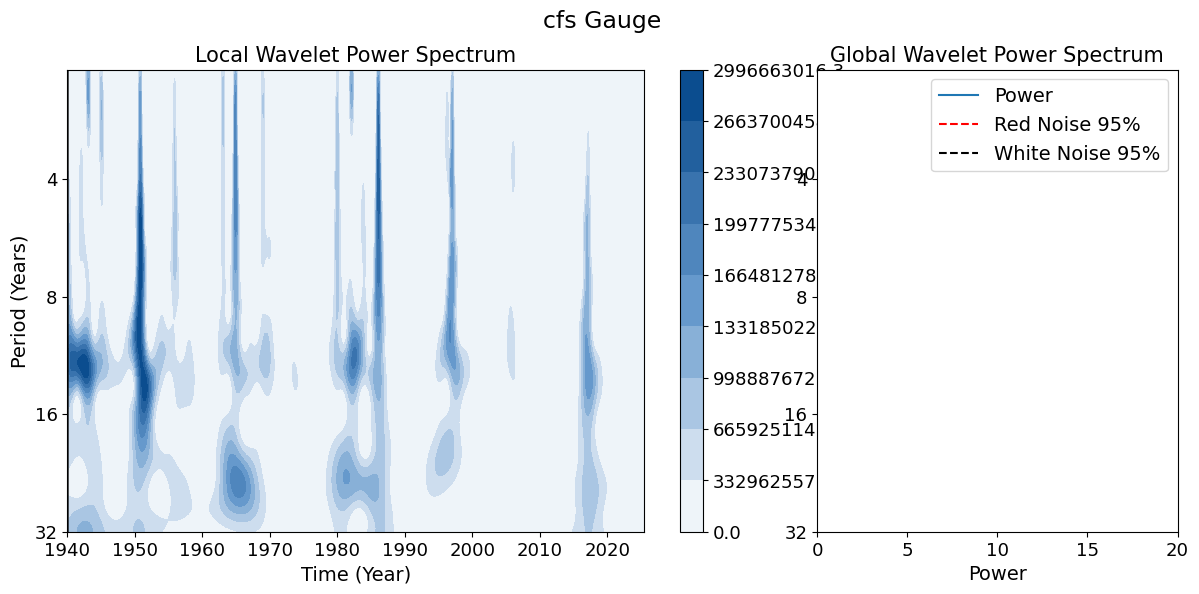

Red Noise Sig Test Results
Significant scales (within COI):
[ 2.    2.03  2.07  2.11  2.14  2.18  2.22  2.26  2.3   2.34  2.38  2.42
  2.46  2.51  2.55  2.59  2.64  2.69  2.73  2.78  2.83  2.88  2.93  2.98
  3.03  3.08  3.14  3.19  3.25  3.31  3.36  3.42  3.48  3.54  3.61  3.67
  3.73  3.8   3.86  3.93  4.    4.07  4.14  4.21  4.29  4.36  4.44  9.85
 10.02 10.2  10.37 10.56 10.74 10.93 11.12 11.31 11.51 11.71 11.92 12.13
 12.34 12.55]


In [36]:
dc_out, dc_sig_scales_all = wa.process_dataframe_columns(
    df=dc,
    cols=['cfs'],
    siglvl=0.95,
    sigtest="default",   # "red", "white", or "default"
    plot_wave=True,      # show local+global spectrum plots
)

<Axes: xlabel='time'>

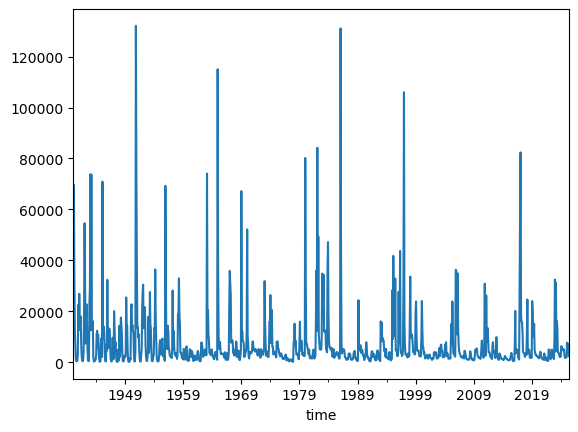

In [45]:
dc_out['cfs'].plot()

In [39]:
dc_out

,cfs,cfs_wave,cfs_wave_lag
time,,,
1940-01-31,24300.0,7569.686213,NaN
1940-02-29,57500.0,7569.686213,7569.686213
1940-03-31,69600.0,8542.934541,7569.686213
1940-04-30,29800.0,789.606036,8542.934541
1940-05-31,11300.0,5804.207509,789.606036
...,...,...,...
2025-02-28,7730.0,9924.465070,4842.431239
2025-03-31,6400.0,5715.761045,9924.465070
2025-04-30,7480.0,7756.517963,5715.761045


<Axes: xlabel='time'>

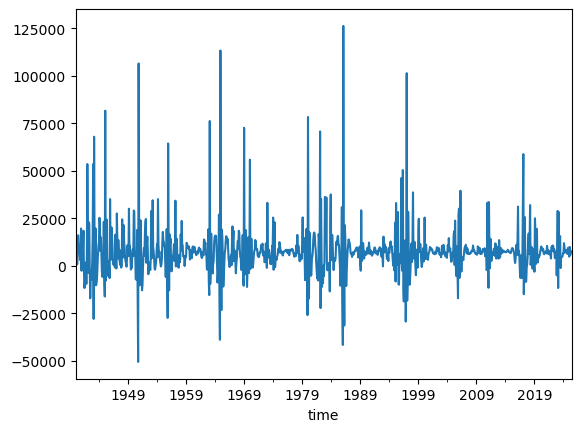

In [46]:
dc_out['cfs_wave'].plot()

Note that the wavelet reconstructed streamflow is nonphysical, showing negative values. 